In [12]:
# This notebook is for adaptive binning HOF fraction plots (logic gaps -> dont use)

# import + def functions 
import pynbody, numpy as np,matplotlib.pyplot as plt
import tarfile, zipfile

# compute adaptive HOF fraction
def adaptive_HOF(masses,Nstar):

    occ_frac_data = []
    mass_data = []

    # set initial occupation fraction + counts
    occ = 0
    total = 0
    occ_frac = 1.0
    prev_occ_frac = 1.0
    
    for halo in range(len(masses)):
        # add to total halo count + occ count if >0 stars then compute new occ_frac
        total += 1
        occ += int(Nstar[halo] > 0)
        occ_frac = occ / total 

        # if bin is larger than previous bin -> add to plotting arrays
        if occ_frac <= prev_occ_frac:
            occ_frac_data.append(occ_frac)
            mass_data.append(masses[halo])
            prev_occ_frac = occ_frac
    return np.array(occ_frac_data),np.array(mass_data)

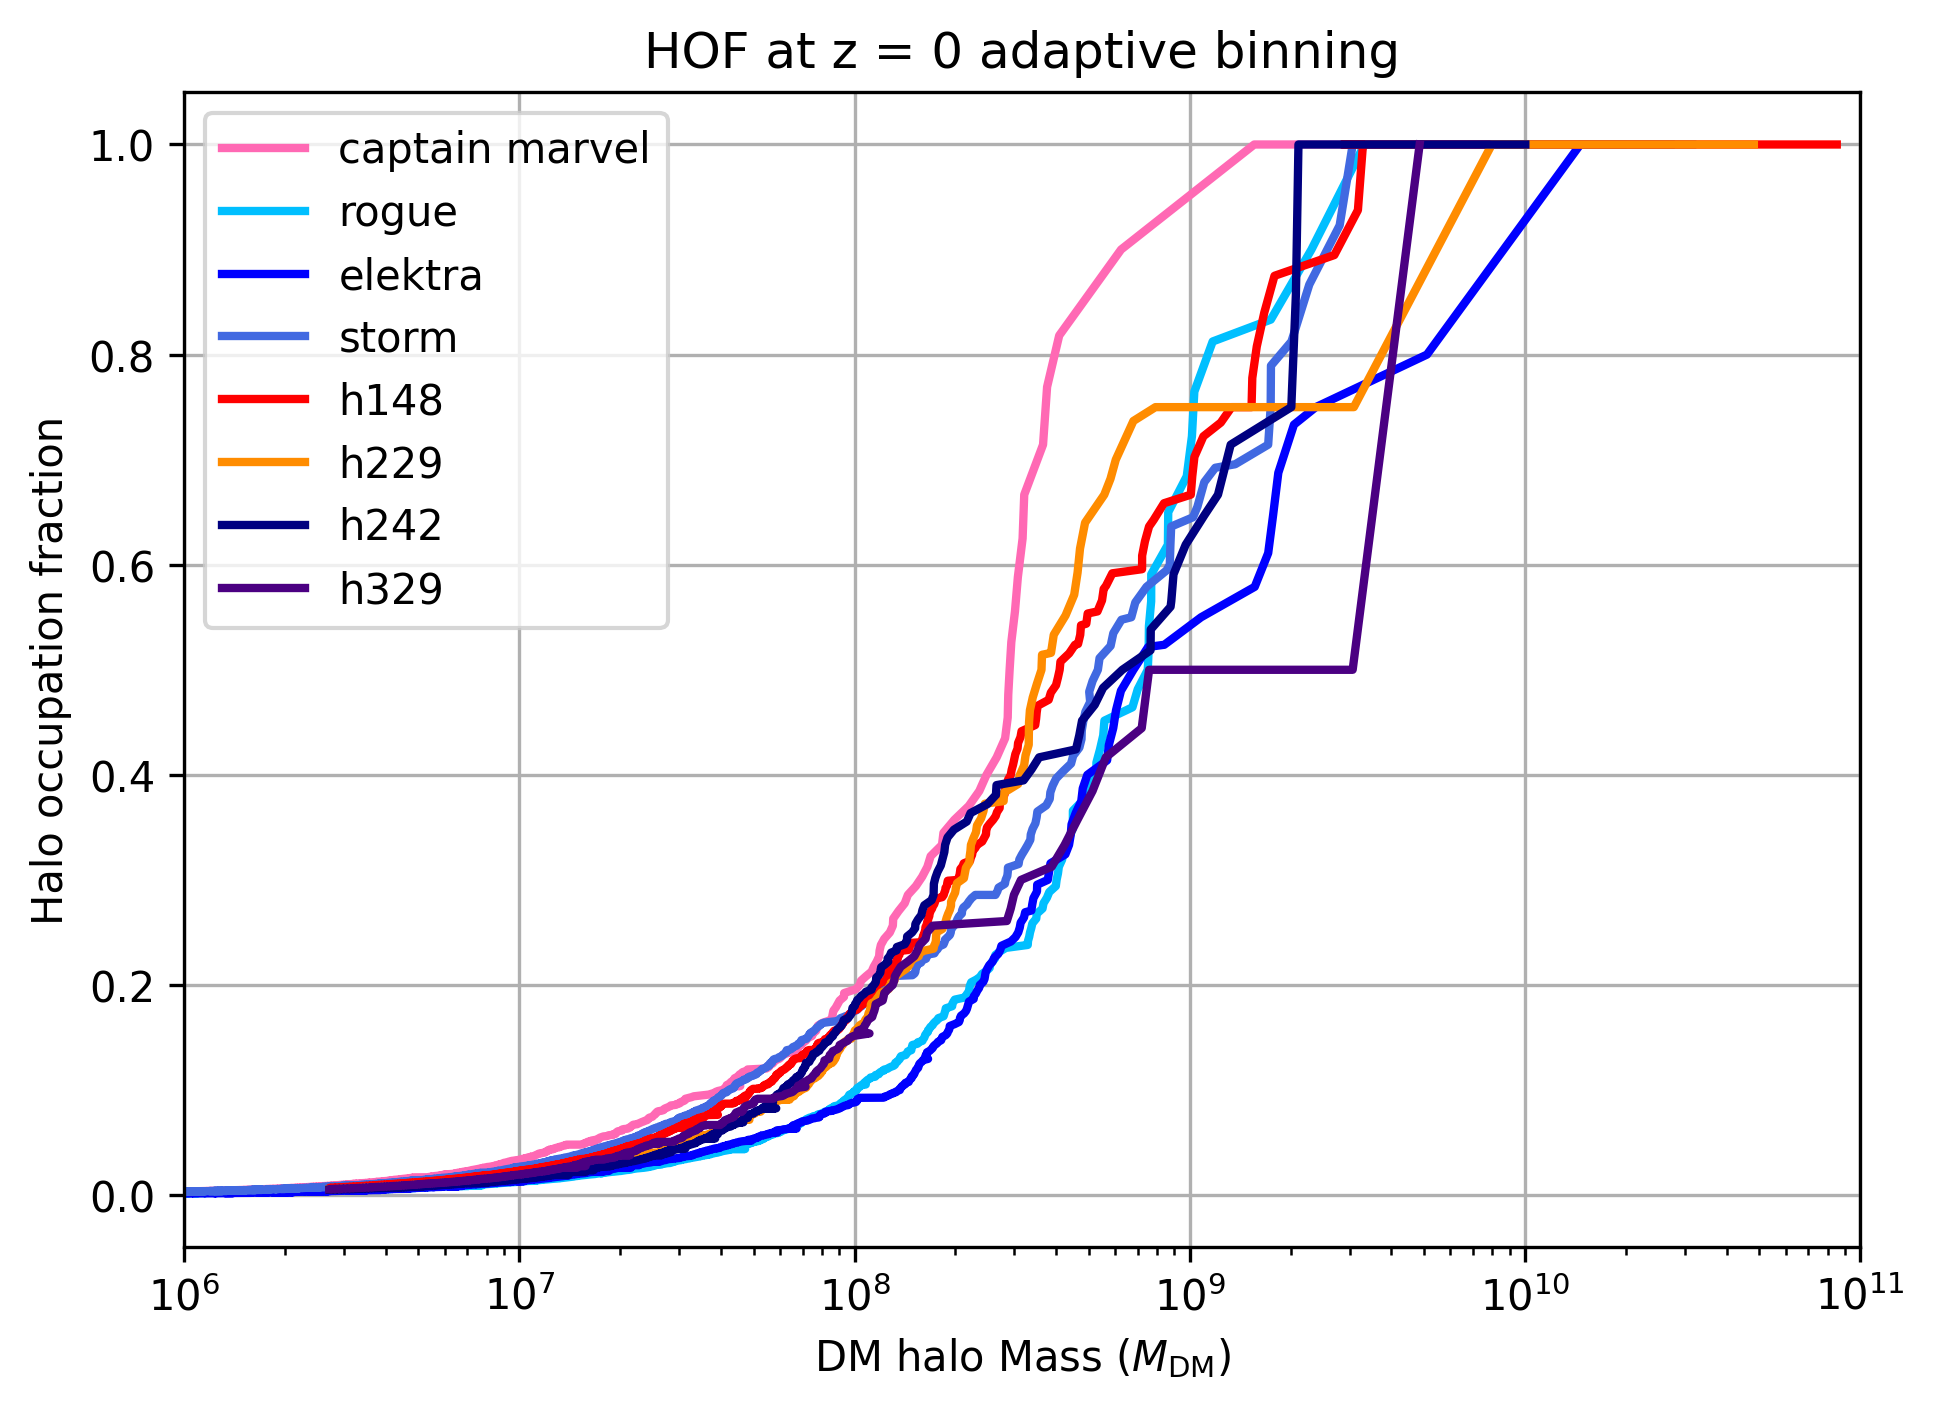

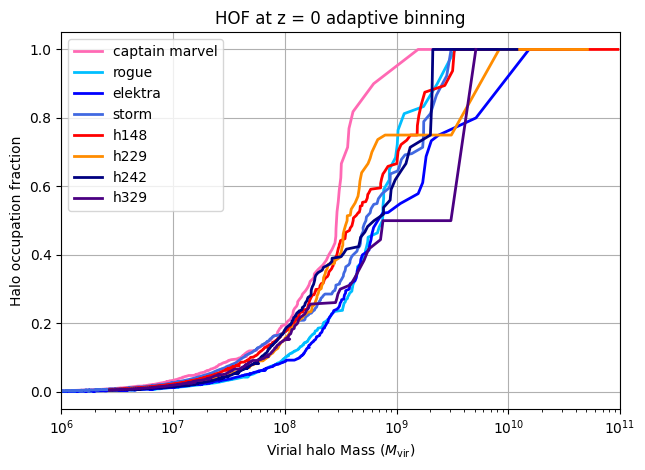

In [10]:
# HOF vs DM mass and Mvir at z=0 Marvel + h sims ADAPTIVE binning
"""
Cummulative HOF at z = 0
Data: Marvel and h stat files
Adaptive binning: add data to bin until occ_frac > prev bin occ_frac -> always increasing 
4/28/25
edited 5/26,6/26
"""
    
# open all sim data files for M200, z=0
cptmarvel = "Stat_Files/cptmarvel.cosmo25cmb.4096g5HbwK1BH/cptmarvel.cosmo25cmb.4096g5HbwK1BH.004096/cptmarvel.cosmo25cmb.4096g5HbwK1BH.004096.amiga.stat"
cptm = np.genfromtxt(cptmarvel, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

rogue = "Stat_Files/rogue.cosmo25cmb.4096g5HbwK1BH/rogue.cosmo25cmb.4096g5HbwK1BH.004096/rogue.cosmo25cmb.4096g5HbwK1BH.004096.amiga.stat"
rg = np.genfromtxt(rogue, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

elektra = "Stat_Files/elektra.cosmo25cmb.4096g5HbwK1BH/elektra.cosmo25cmb.4096g5HbwK1BH.004096/elektra.cosmo25cmb.4096g5HbwK1BH.004096.amiga.stat"
elk = np.genfromtxt(elektra, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

storm = "Stat_Files/storm.cosmo25cmb.4096g5HbwK1BH/storm.cosmo25cmb.4096g5HbwK1BH.004096/storm.cosmo25cmb.4096g5HbwK1BH.004096.amiga.stat"
stm = np.genfromtxt(storm, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

h148 = "Stat_Files/h148.cosmo50PLK.3072g3HbwK1BH/h148.cosmo50PLK.3072g3HbwK1BH.004096/h148.cosmo50PLK.3072g3HbwK1BH.004096.amiga.stat"
h1 = np.genfromtxt(h148, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

h229 = "Stat_Files/h229.cosmo50PLK.3072gst5HbwK1BH/h229.cosmo50PLK.3072gst5HbwK1BH.004096/h229.cosmo50PLK.3072gst5HbwK1BH.004096.amiga.stat"
h2 = np.genfromtxt(h229, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

h242 = "Stat_Files/h242.cosmo50PLK.3072gst5HbwK1BH/h242.cosmo50PLK.3072gst5HbwK1BH.004096/h242.cosmo50PLK.3072gst5HbwK1BH.004096.amiga.stat"
h3 = np.genfromtxt(h242, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

h329 = "Stat_Files/h329.cosmo50PLK.3072gst5HbwK1BH/h329.cosmo50PLK.3072gst5HbwK1BH.004096/h329.cosmo50PLK.3072gst5HbwK1BH.004096.amiga.stat"
h4 = np.genfromtxt(h329, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

# reconfigure data by type rather than by sim
Nstar = [ (cptm[:,0]), (rg[:,0]), (elk[:,0]), (stm[:,0]), (h1[:,0]), (h2[:,0]), (h3[:,0]), (h4[:,0])]
vir_mass = [ (cptm[:,1]), (rg[:,1]), (elk[:,1]), (stm[:,1]), (h1[:,1]), (h2[:,1]), (h3[:,1]), (h4[:,1])]
DM_mass = [ (cptm[:,2]), (rg[:,2]), (elk[:,2]), (stm[:,2]), (h1[:,2]), (h2[:,2]), (h3[:,2]), (h4[:,2])]

n_sims = 8

# make plot 
plt.figure(dpi = 300)
colors = np.array(['hotpink', 'deepskyblue', 'blue', 'royalblue', 'red', 'darkorange', 'navy', 'indigo'])
labels = np.array(['captain marvel', 'rogue', 'elektra', 'storm', 'h148', 'h229', 'h242', 'h329', 'h516'])

# loop through each simulation to make DM mass plot
for sim in range(n_sims):

    # get data for this sim
    masses = DM_mass[sim]
    Nstars = Nstar[sim]

    occ_frac_data, DM_mass_data = adaptive_HOF(masses,Nstars)

    plt.semilogx(DM_mass_data, occ_frac_data, linestyle='-', linewidth = 2, color = colors[sim], label = labels[sim])
plt.xlabel(r'DM halo Mass ($M_\text{DM}$)')
plt.ylabel('Halo occupation fraction')
plt.title('HOF at z = 0 adaptive binning')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.xlim(1e6,1e11)
plt.show()

# loop through each simulation to make virial mass plot
for sim in range(n_sims):

    # get data for this sim
    masses = vir_mass[sim]
    Nstars = Nstar[sim]

    occ_frac_data, vir_mass_data = adaptive_HOF(masses,Nstars)
    
    plt.semilogx(vir_mass_data, occ_frac_data, linestyle='-', linewidth = 2, color = colors[sim], label = labels[sim])
plt.xlabel(r'Virial halo Mass ($M_{\mathrm{vir}}$)')
plt.ylabel('Halo occupation fraction')
plt.title('HOF at z = 0 adaptive binning')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.xlim(1e6,1e11)
plt.show()

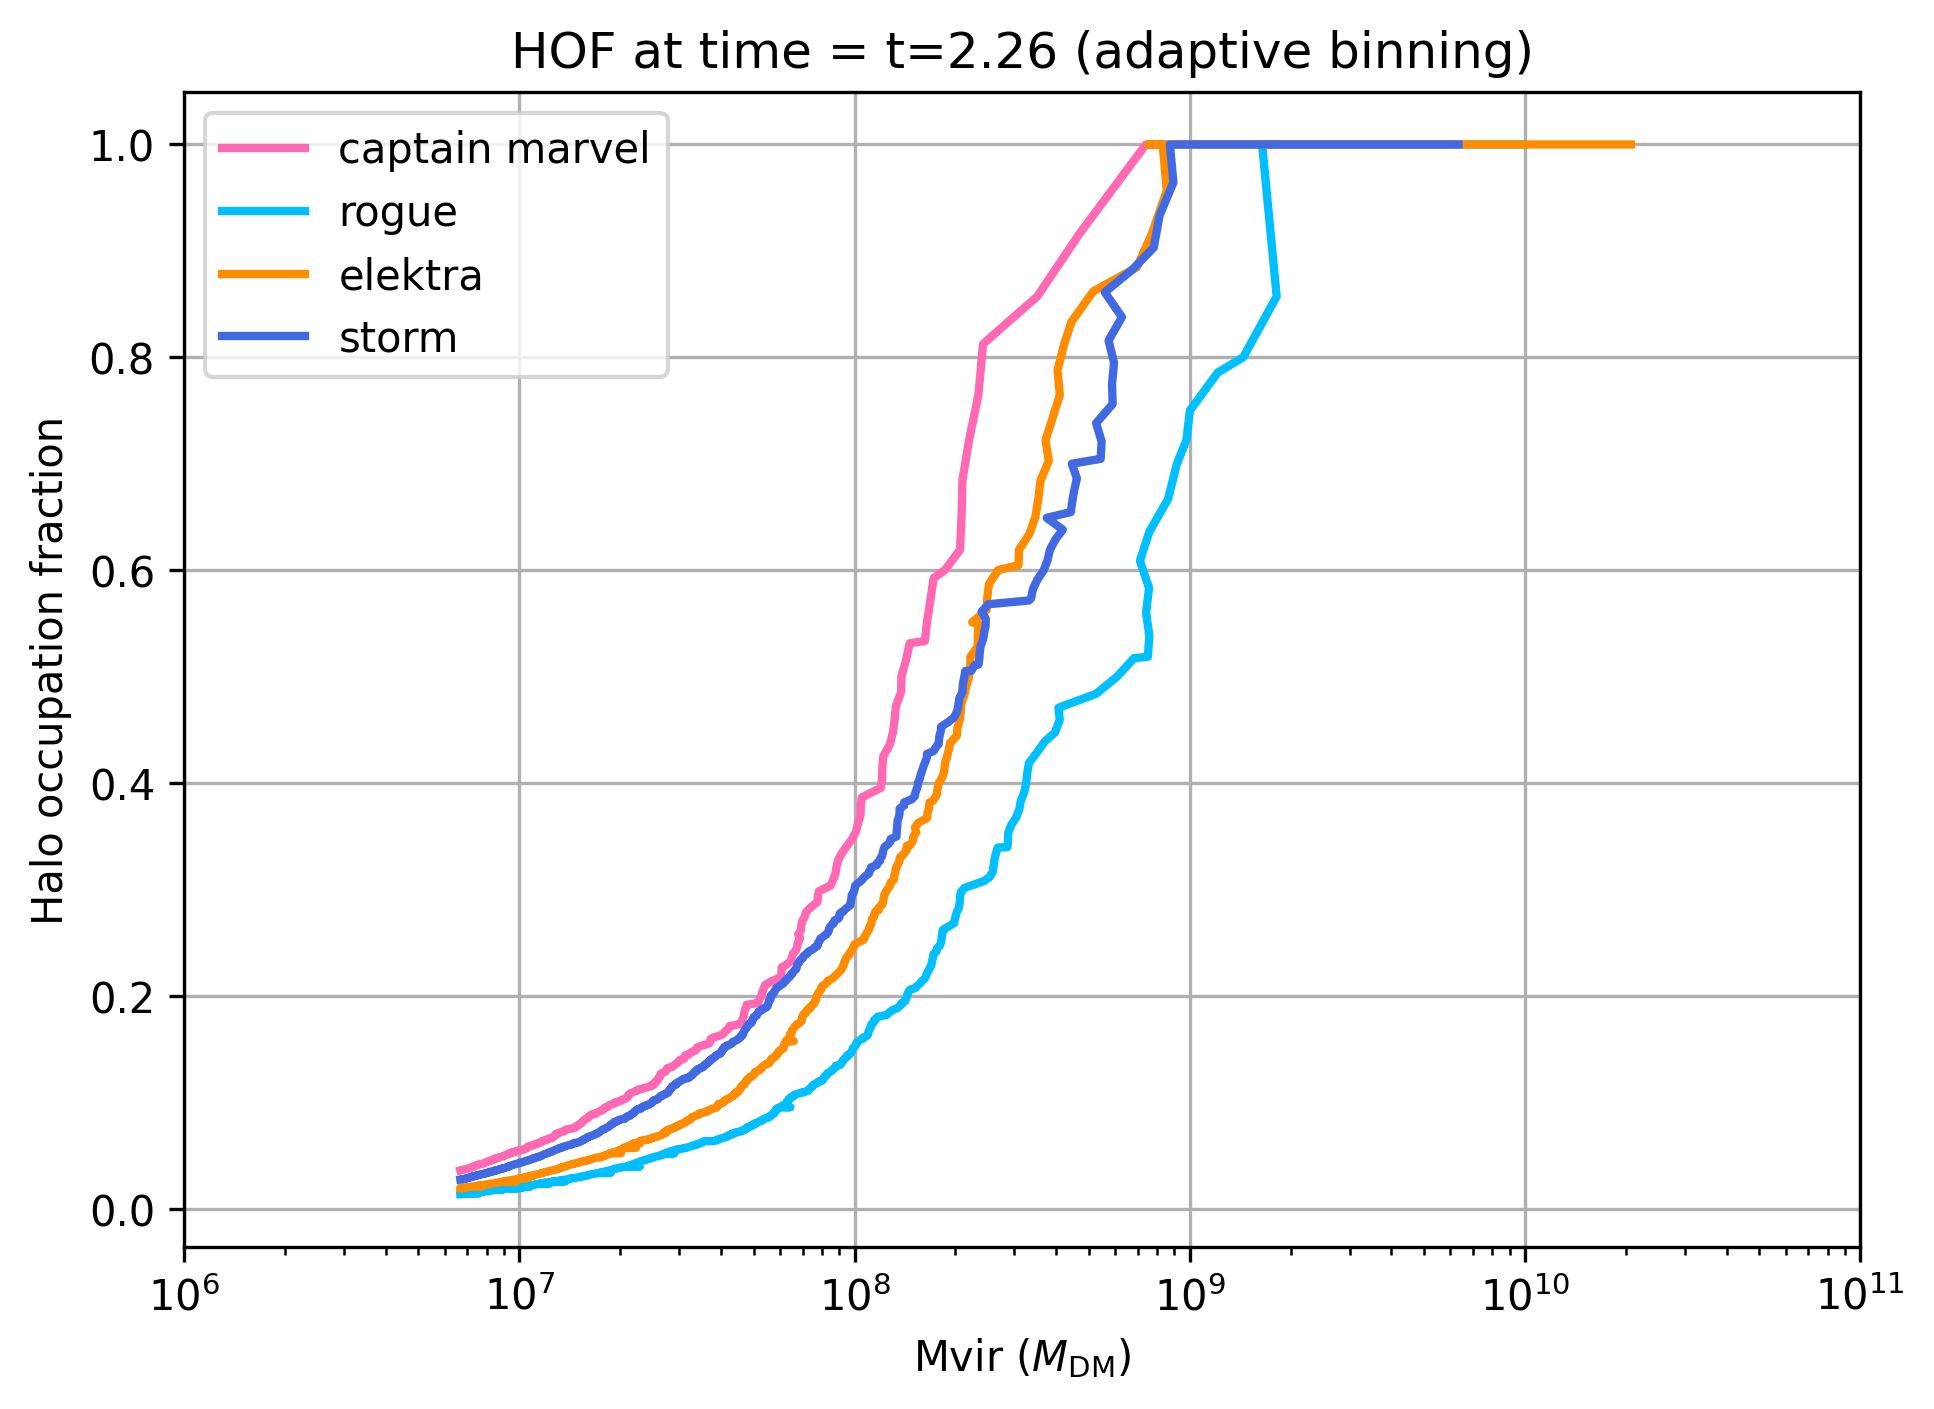

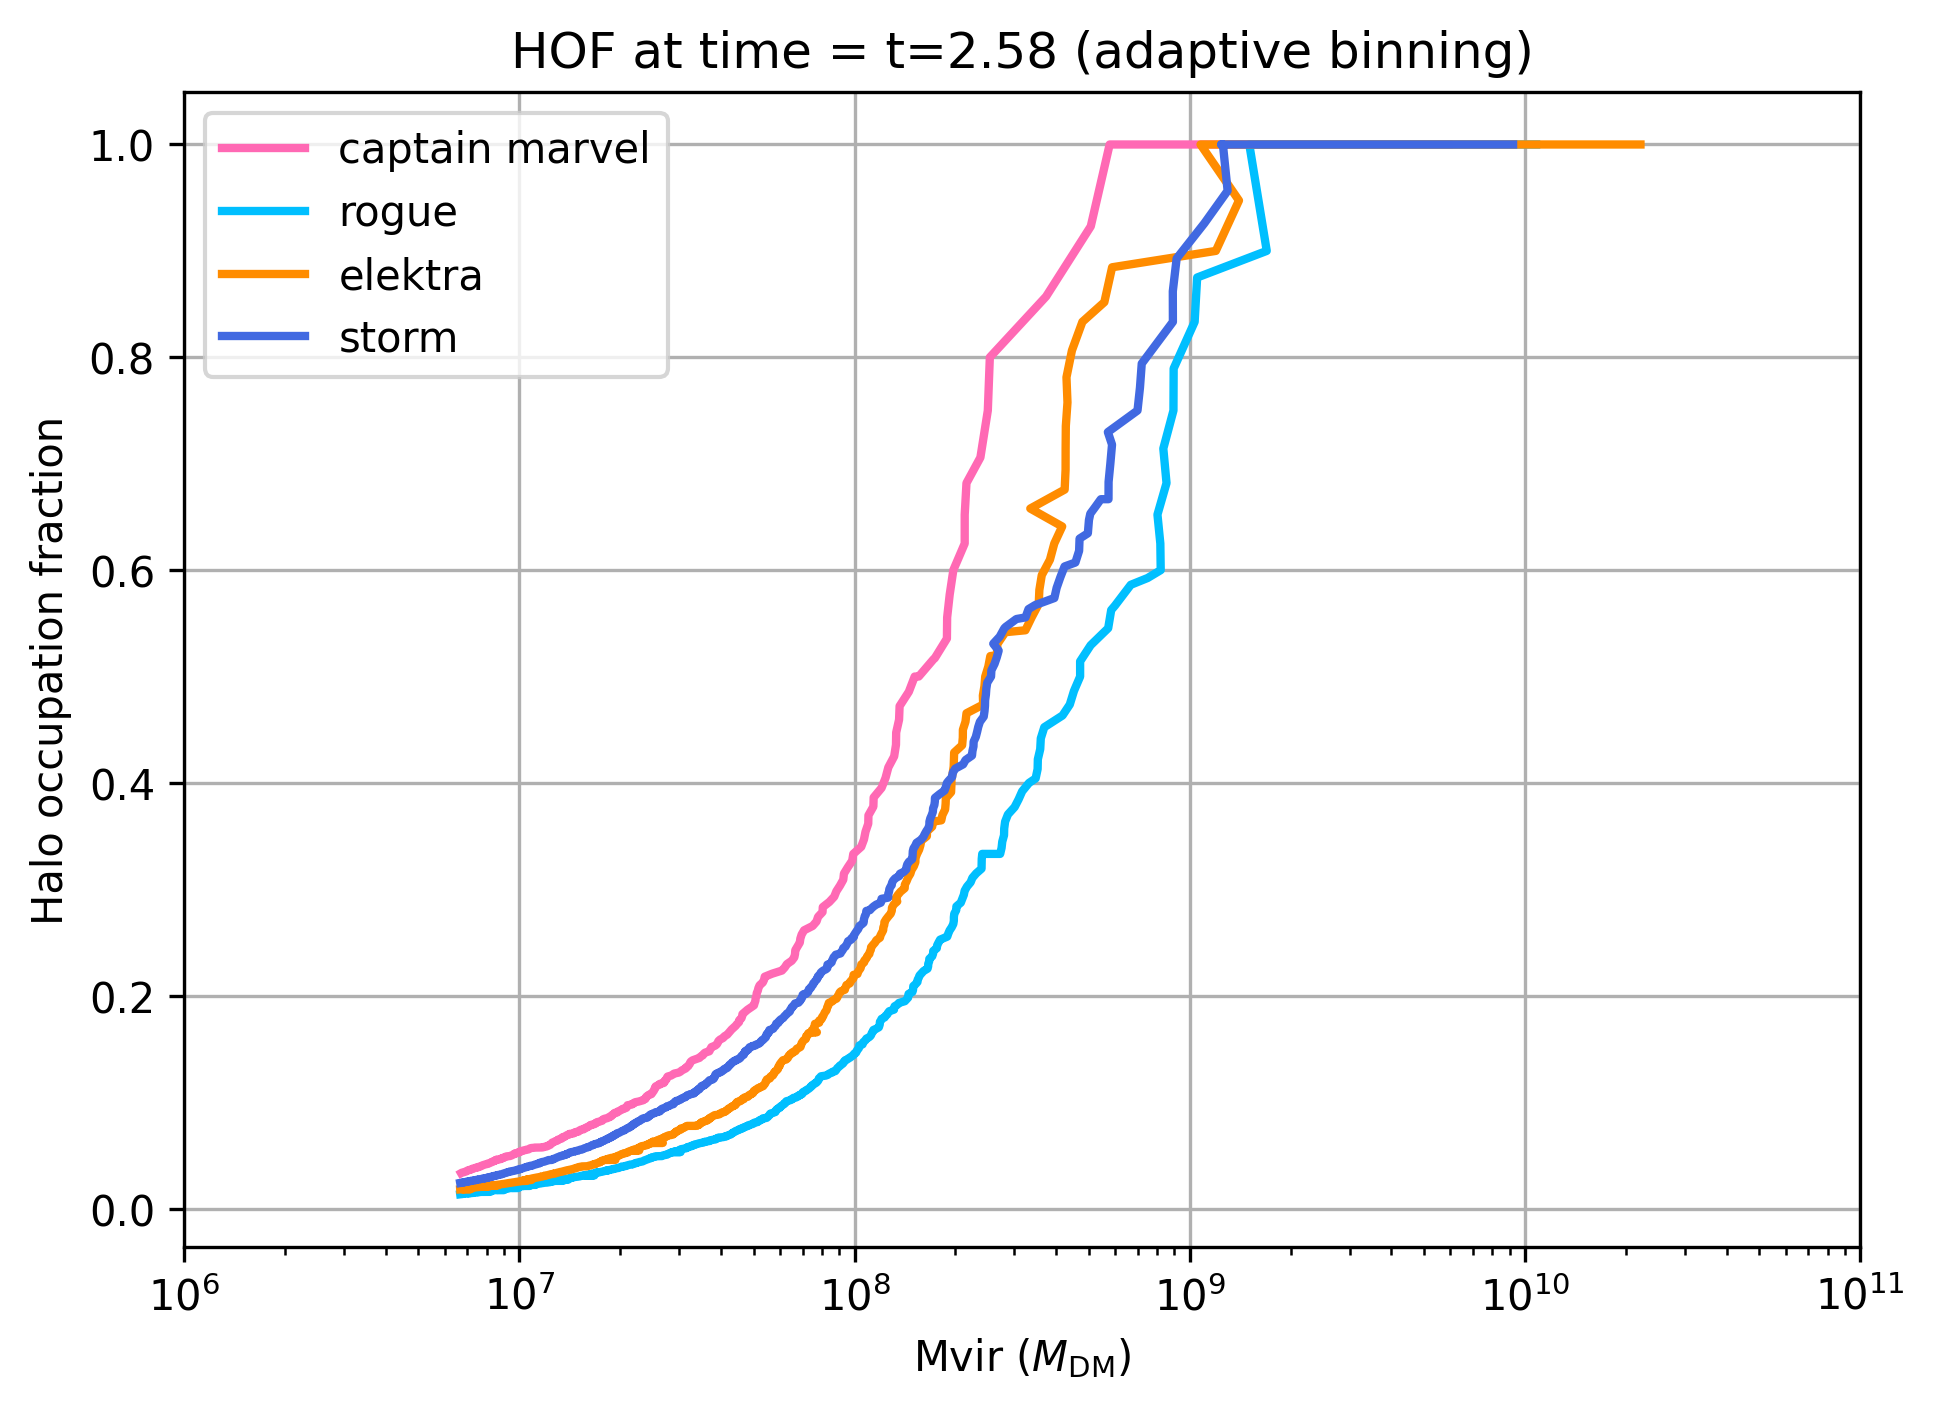

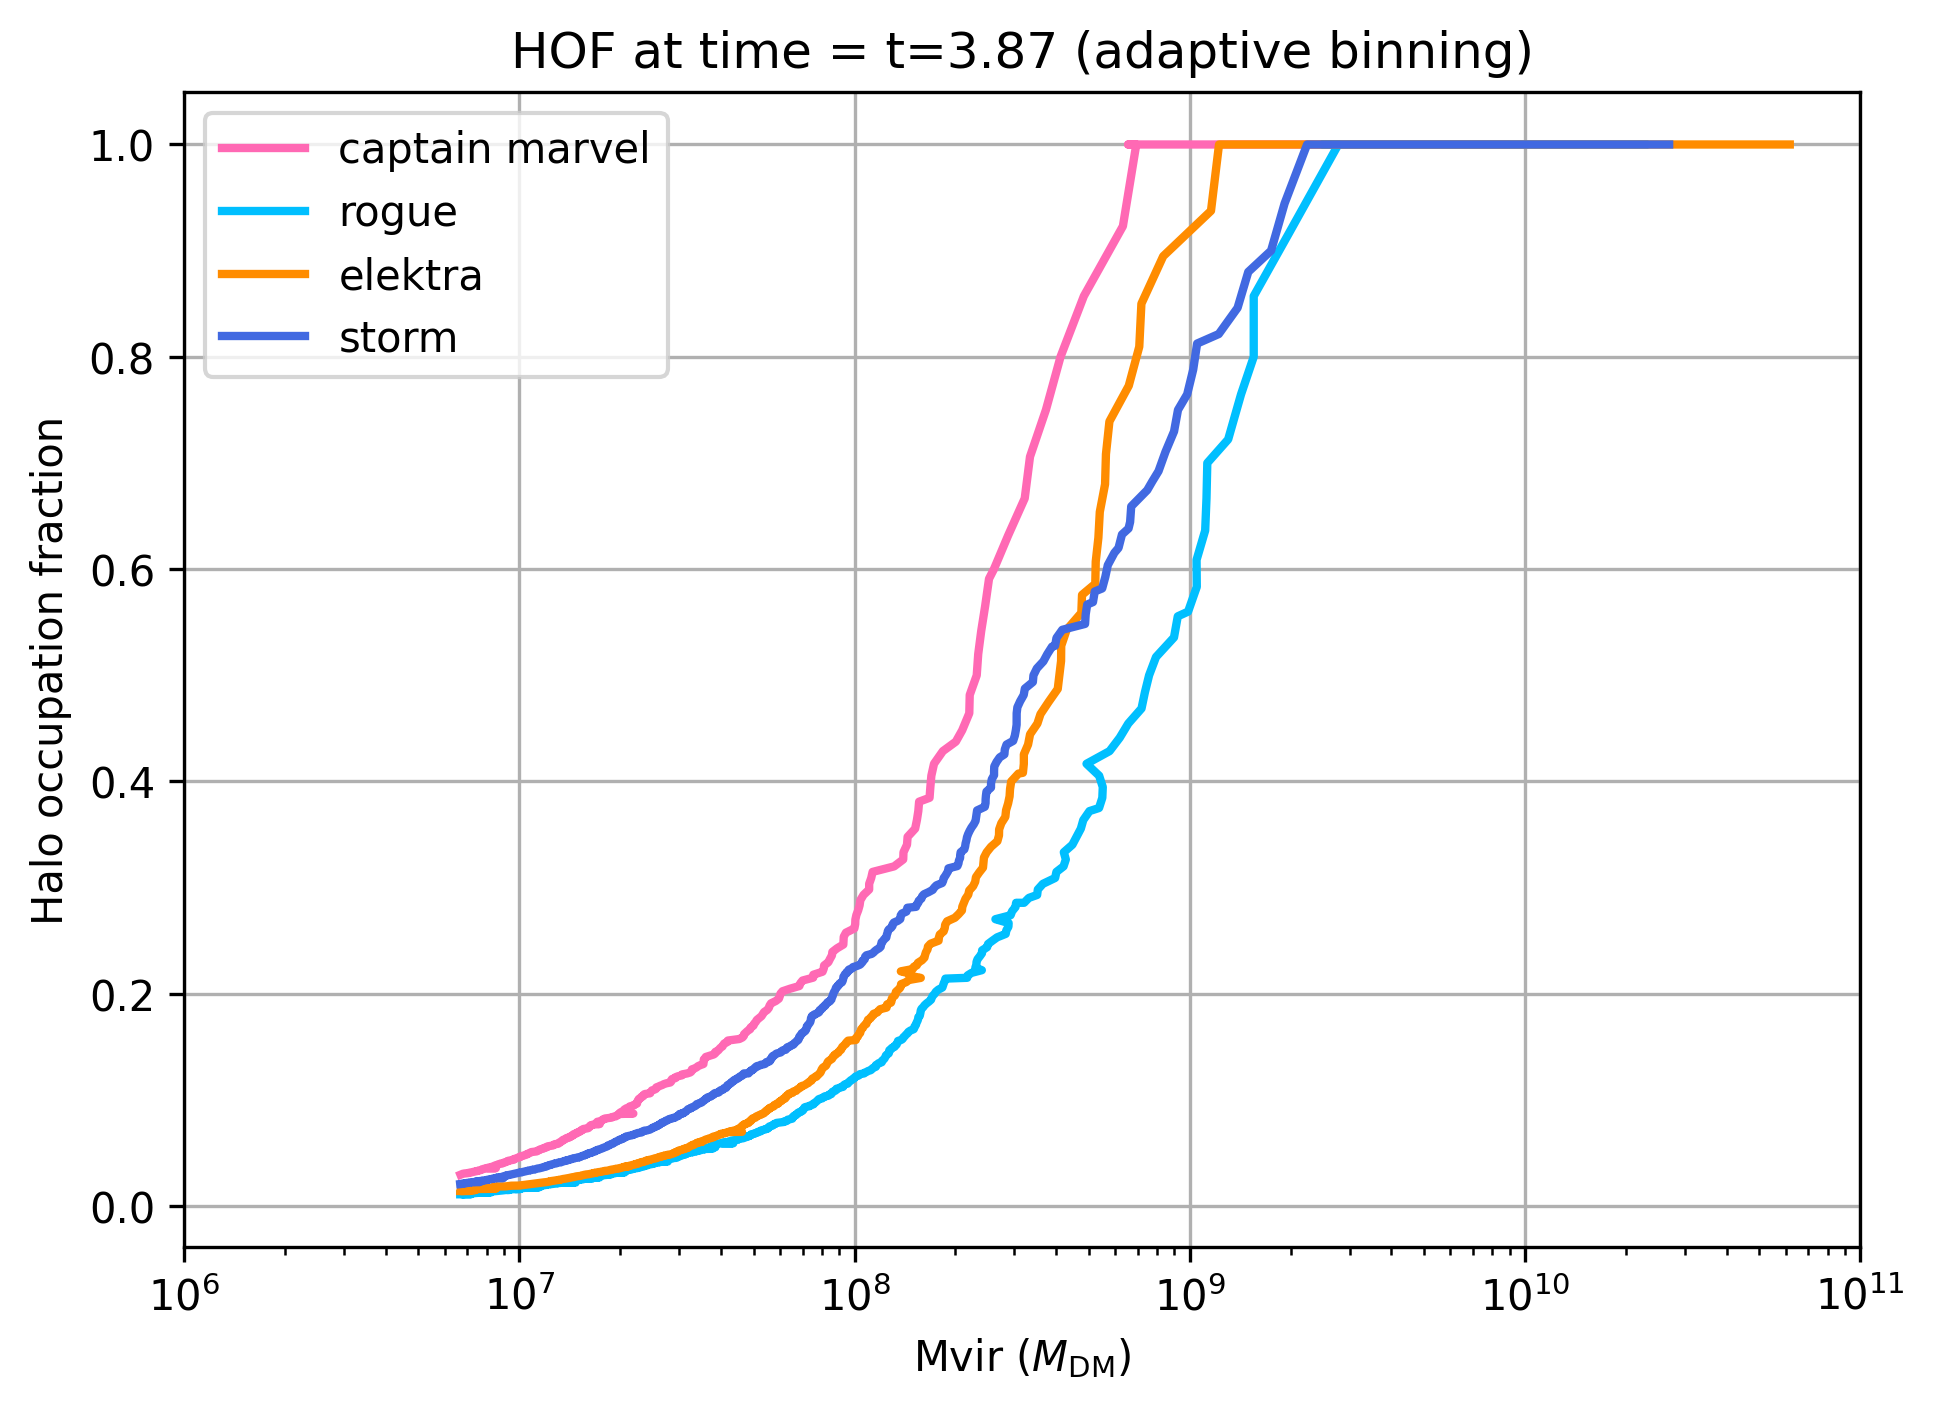

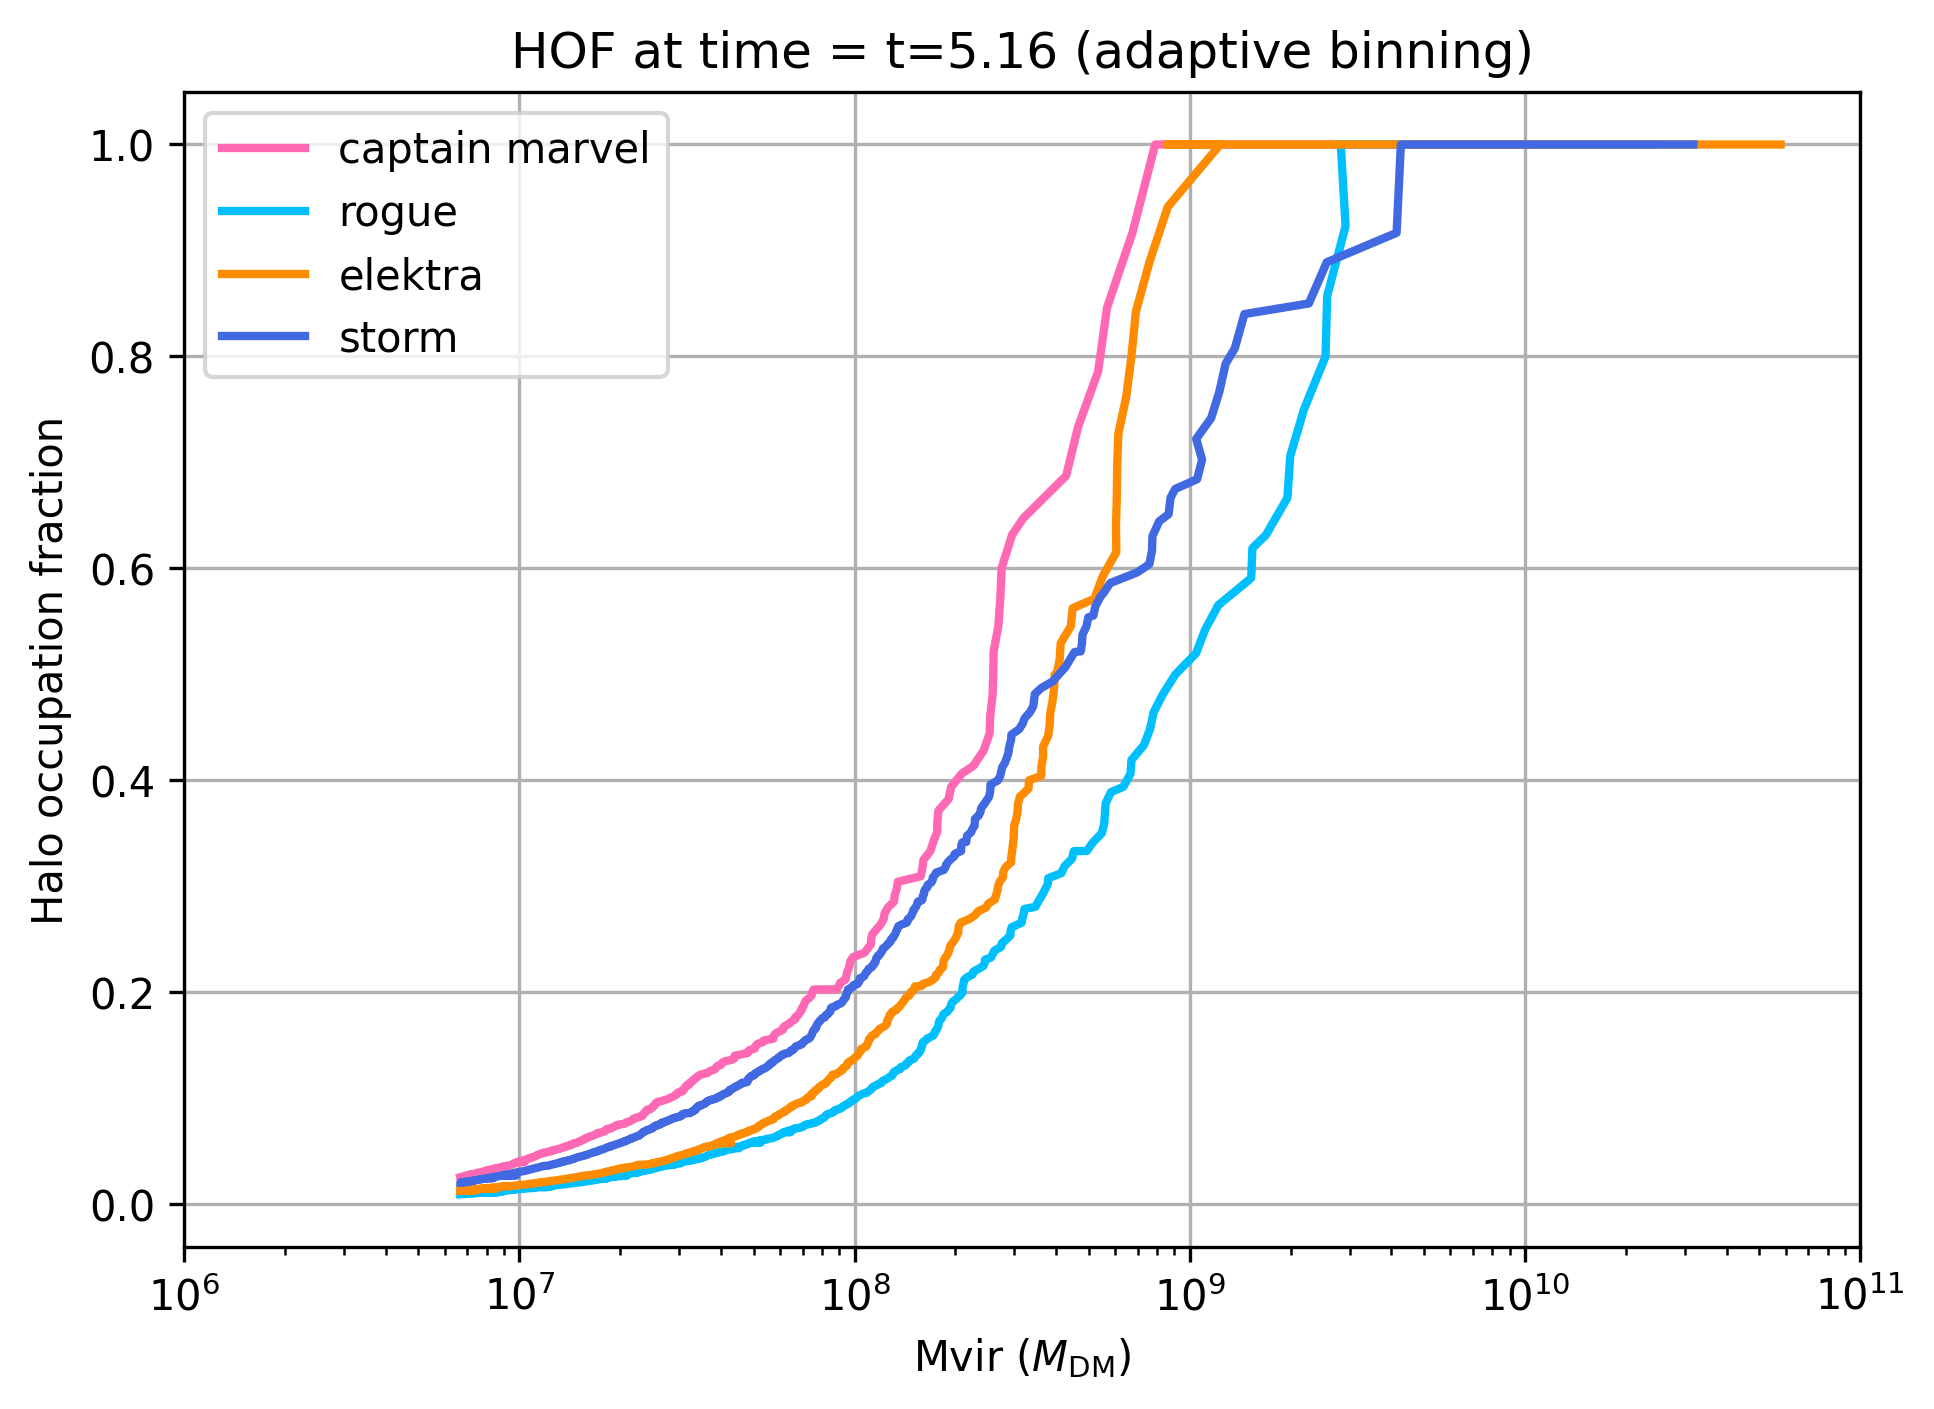

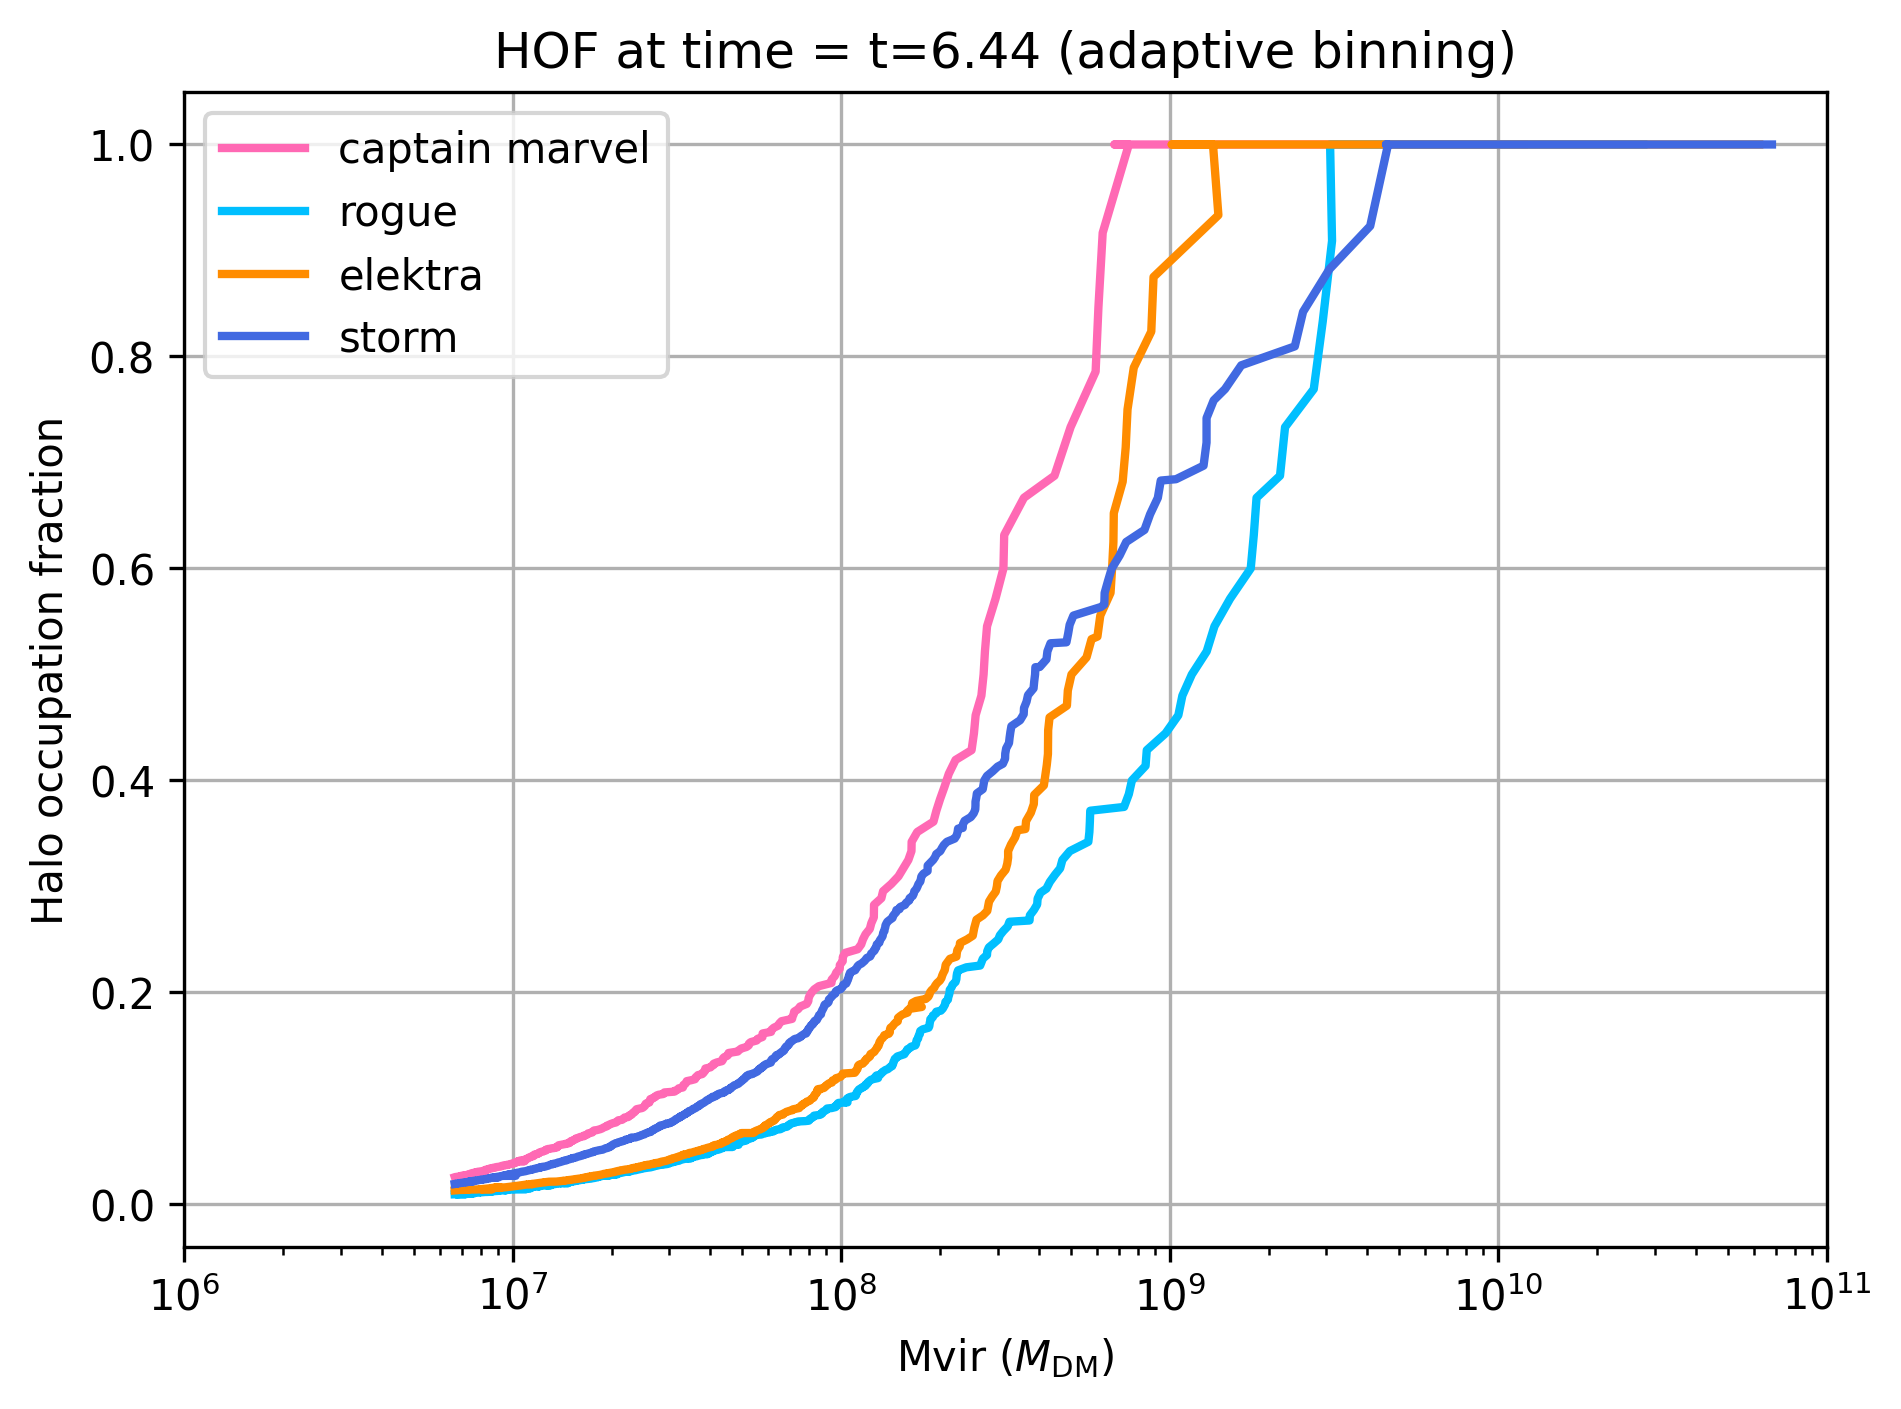

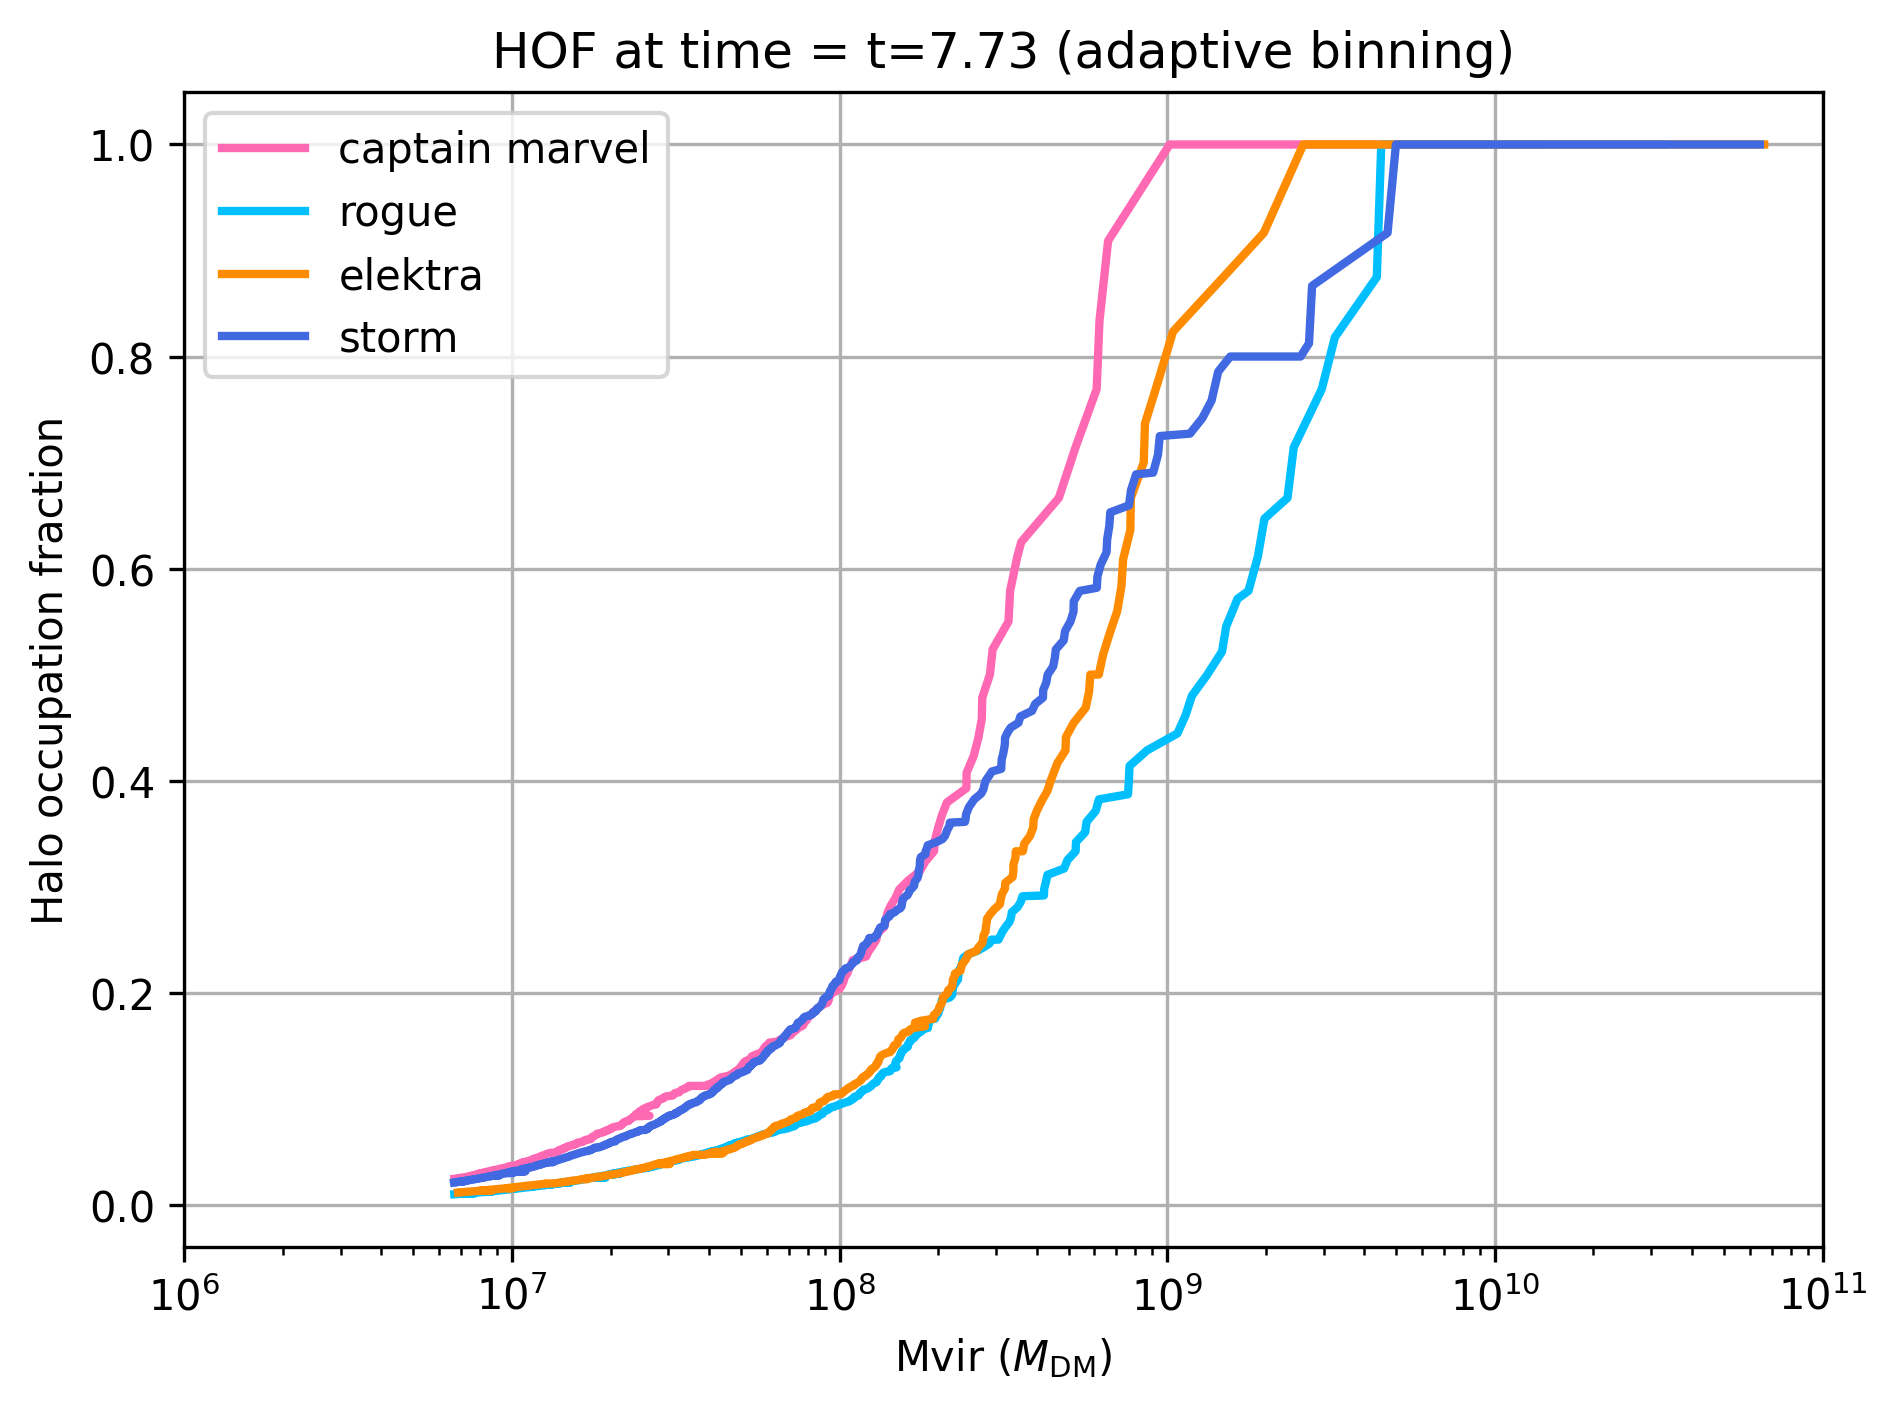

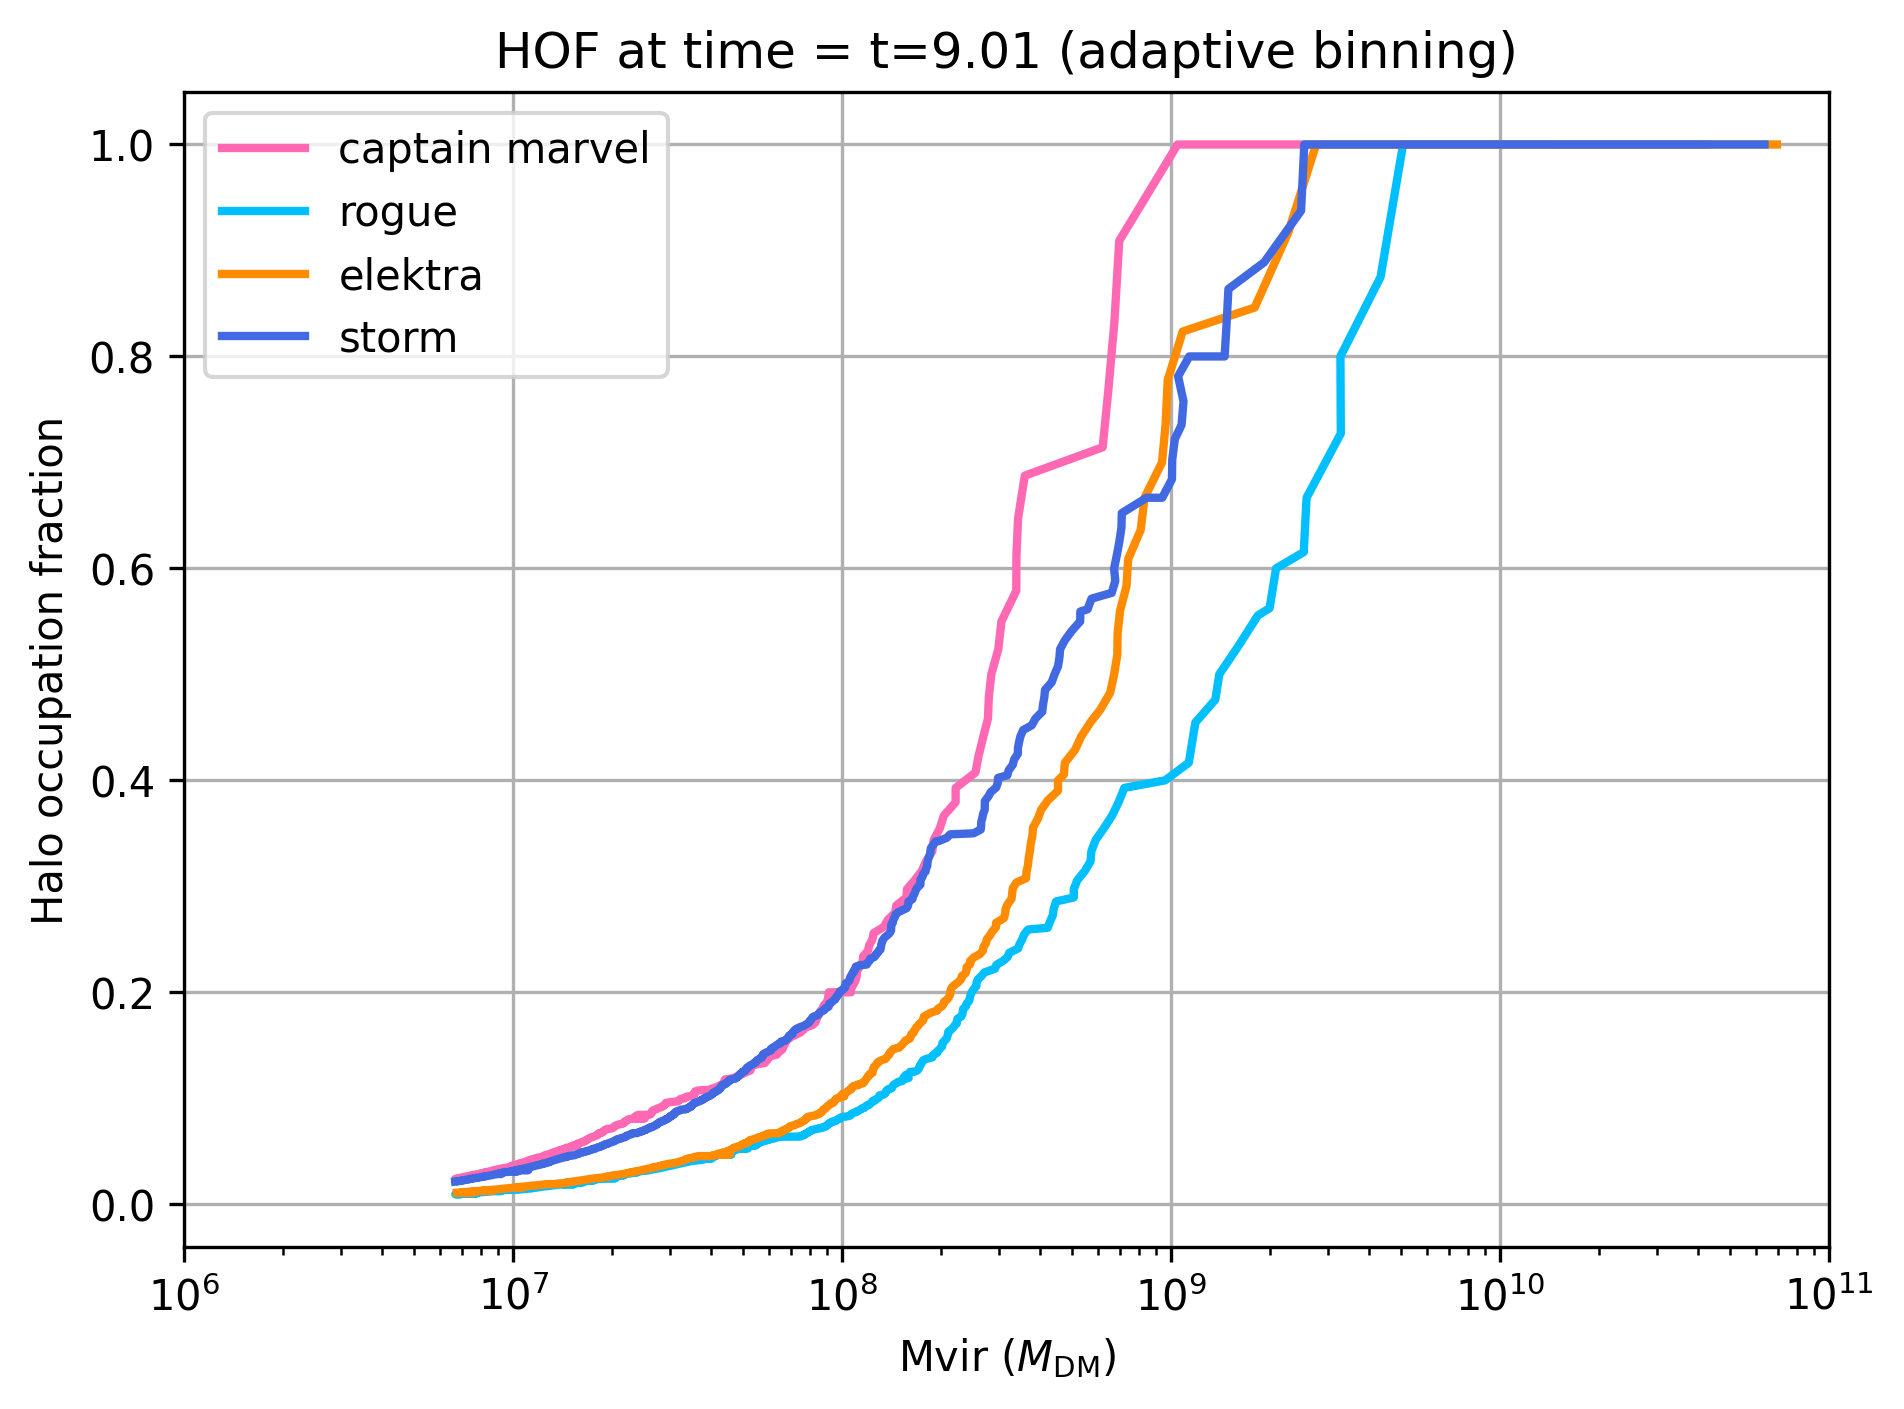

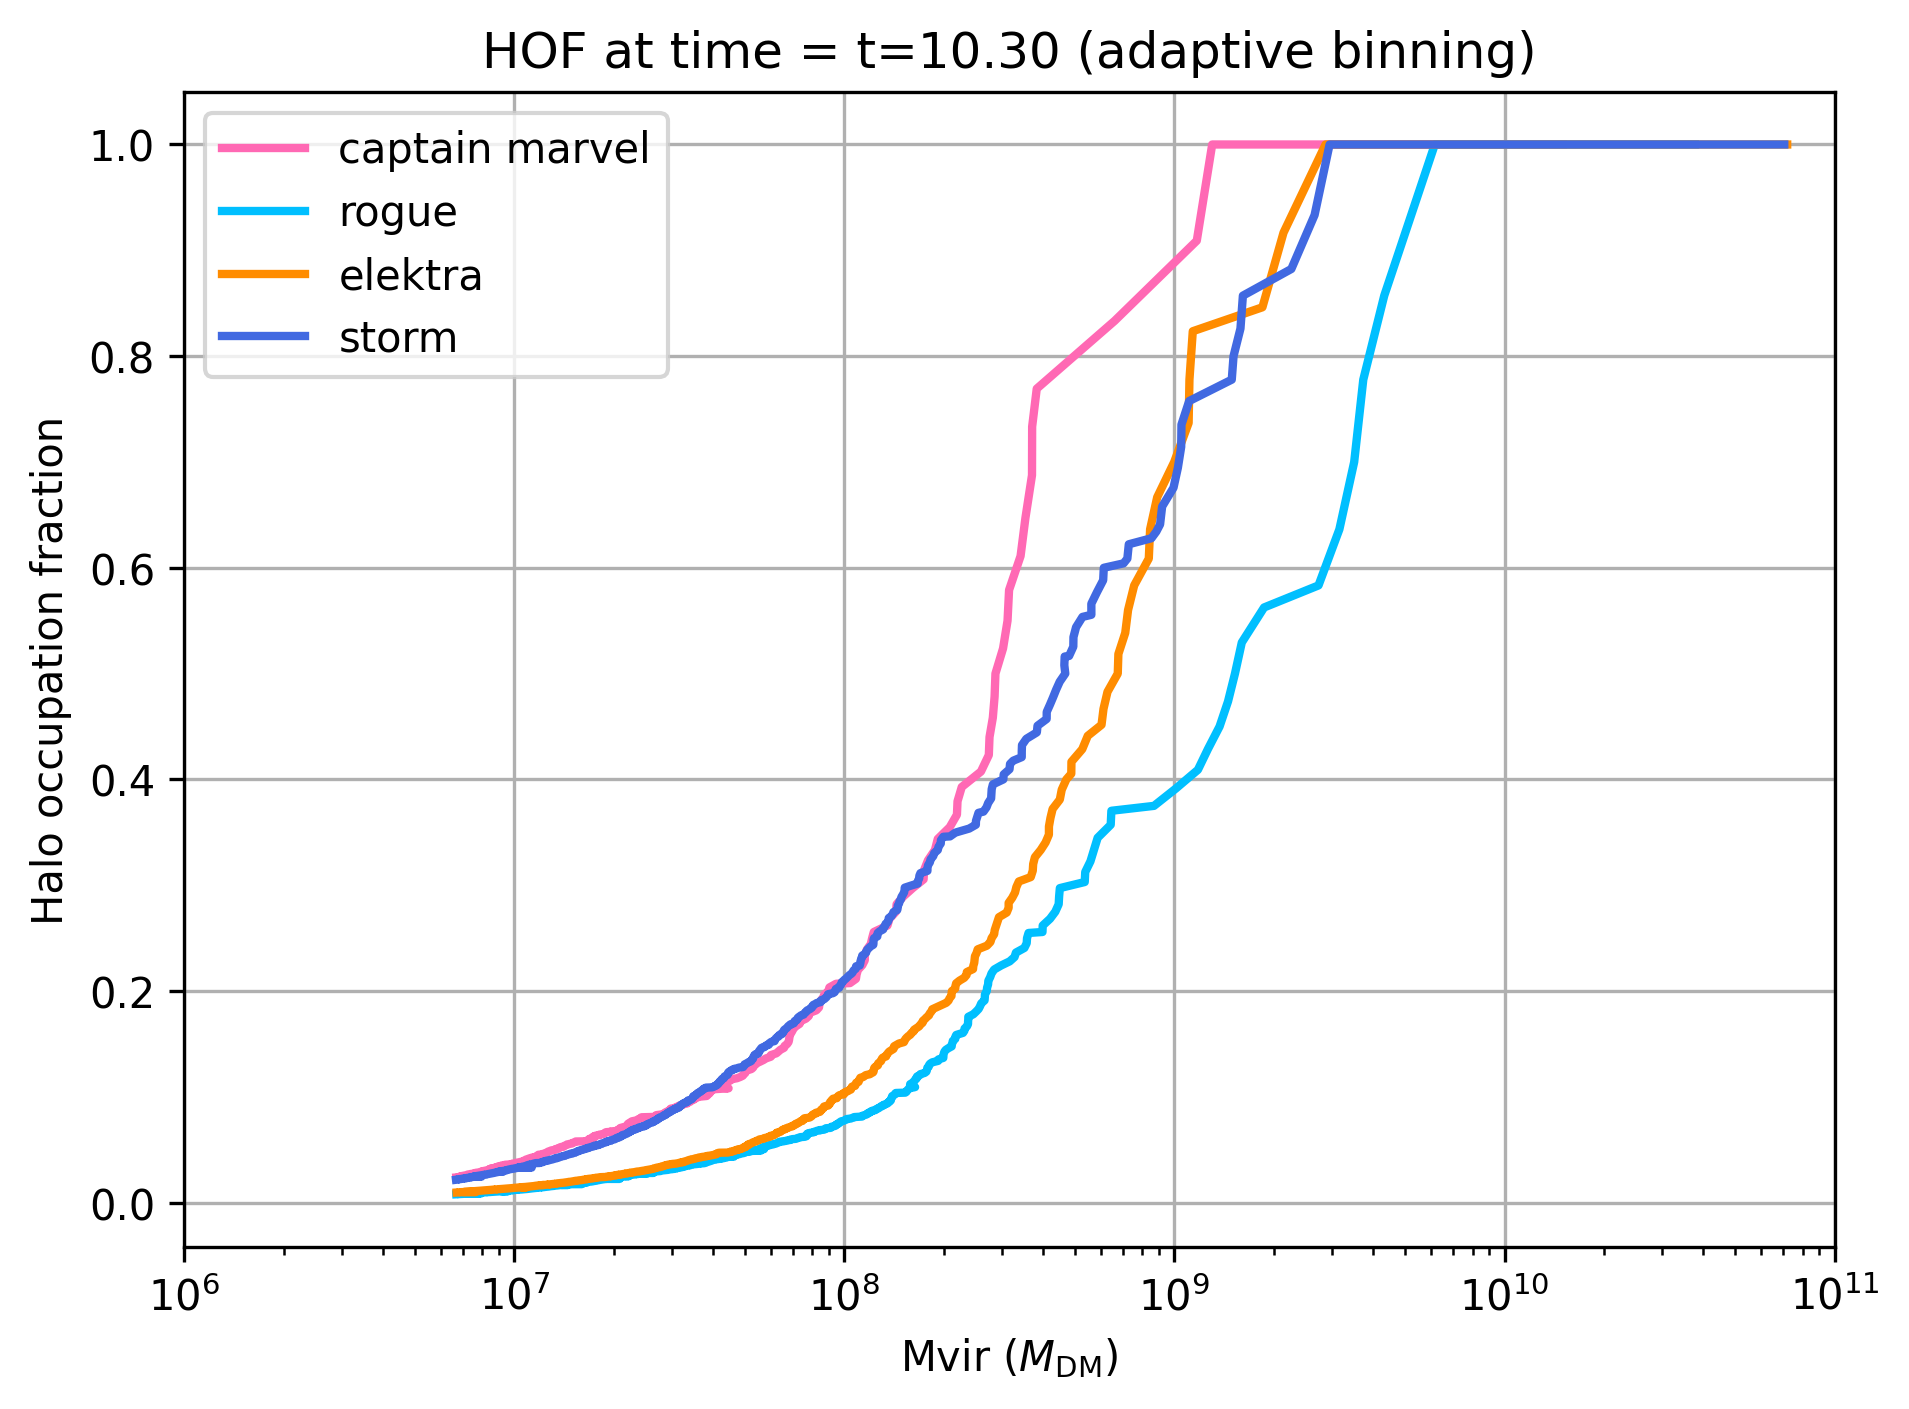

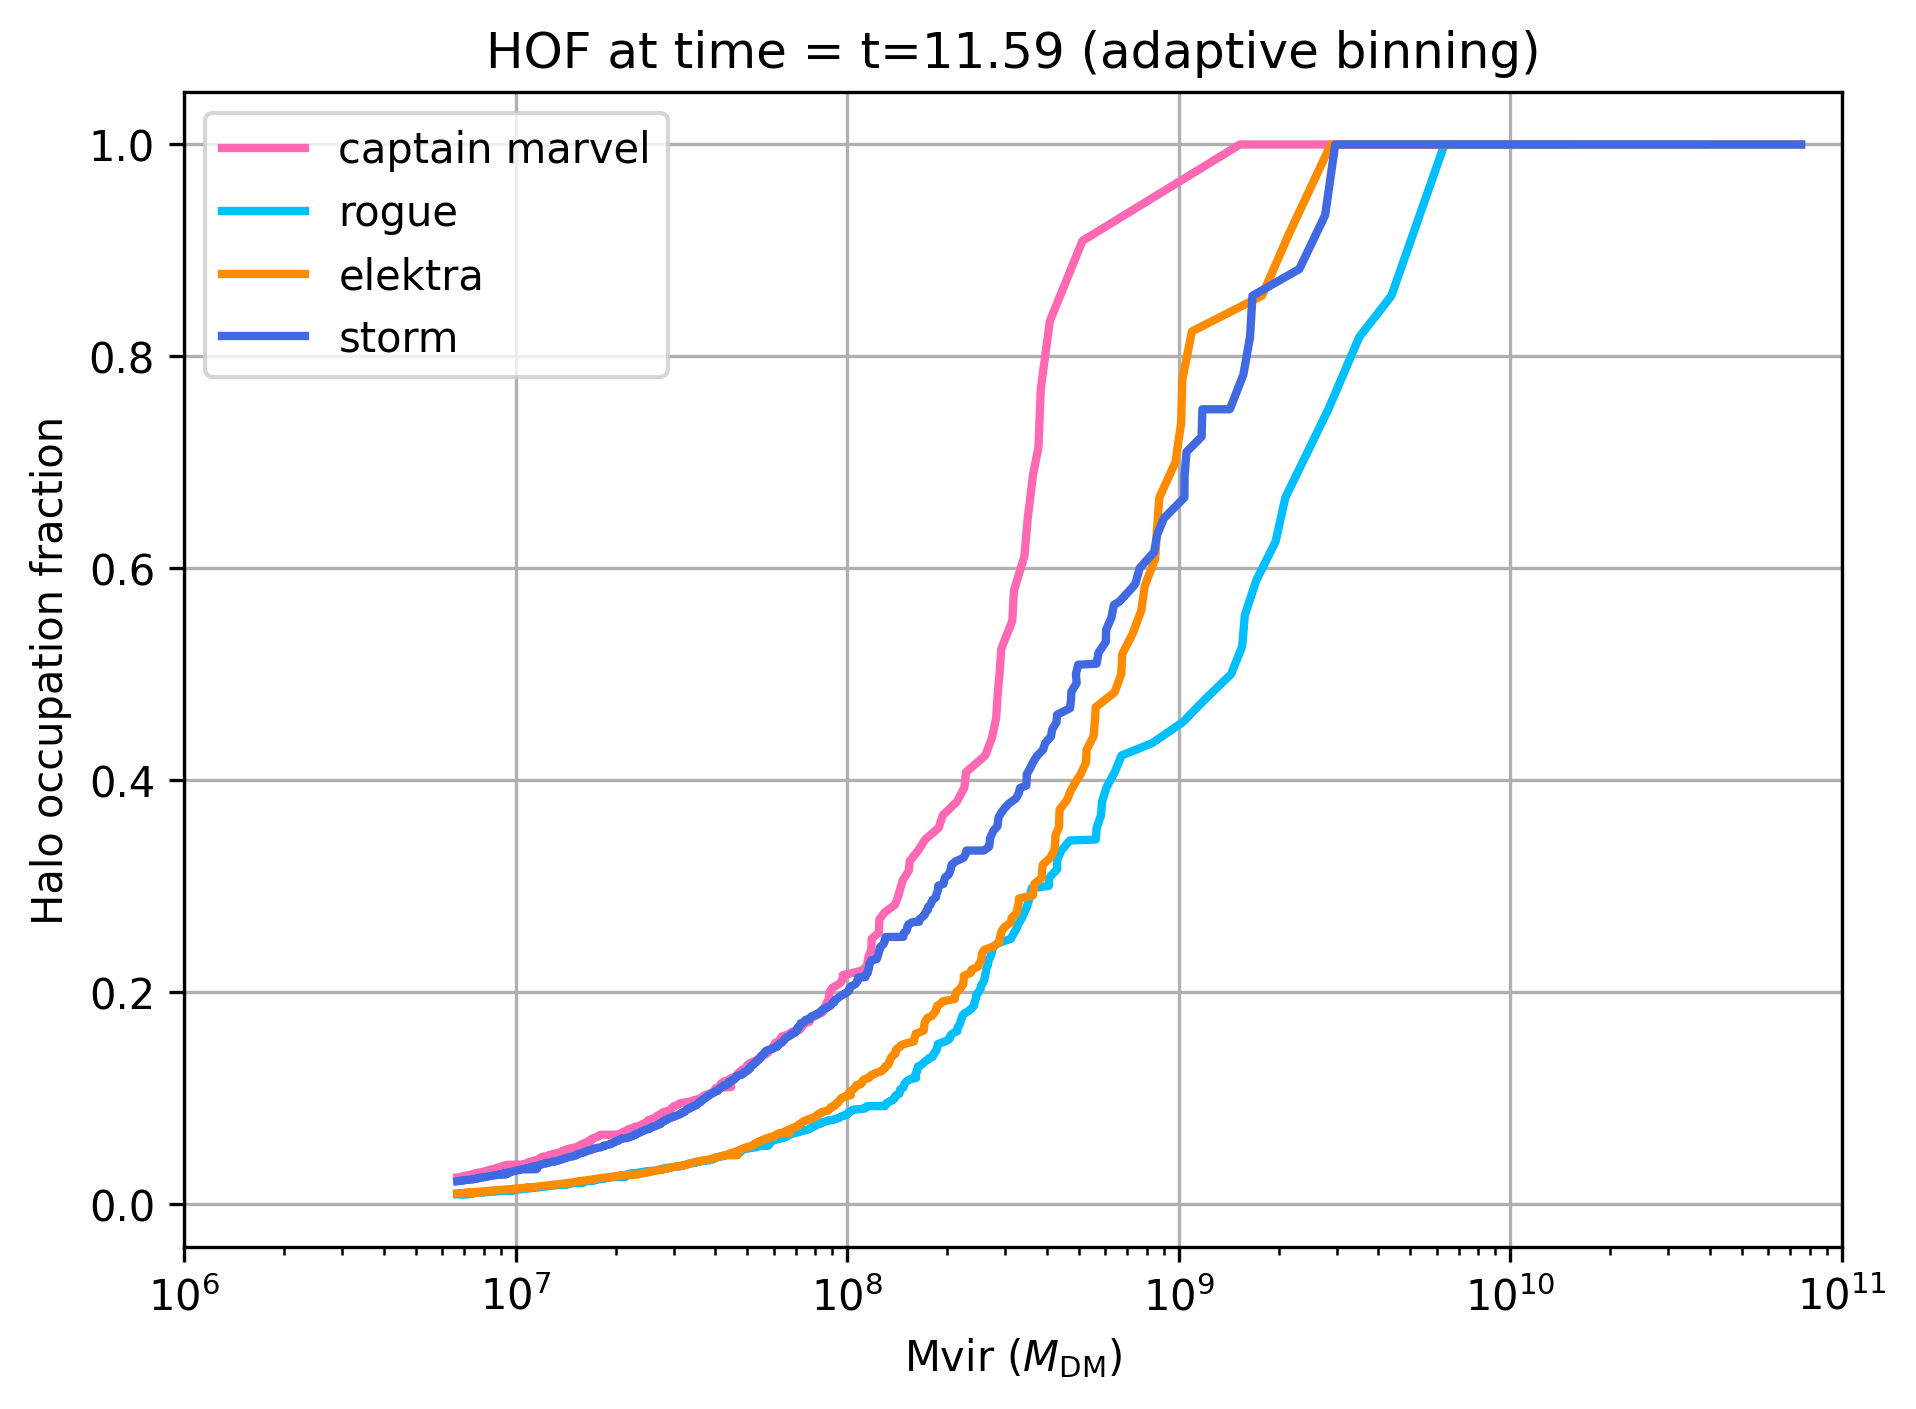

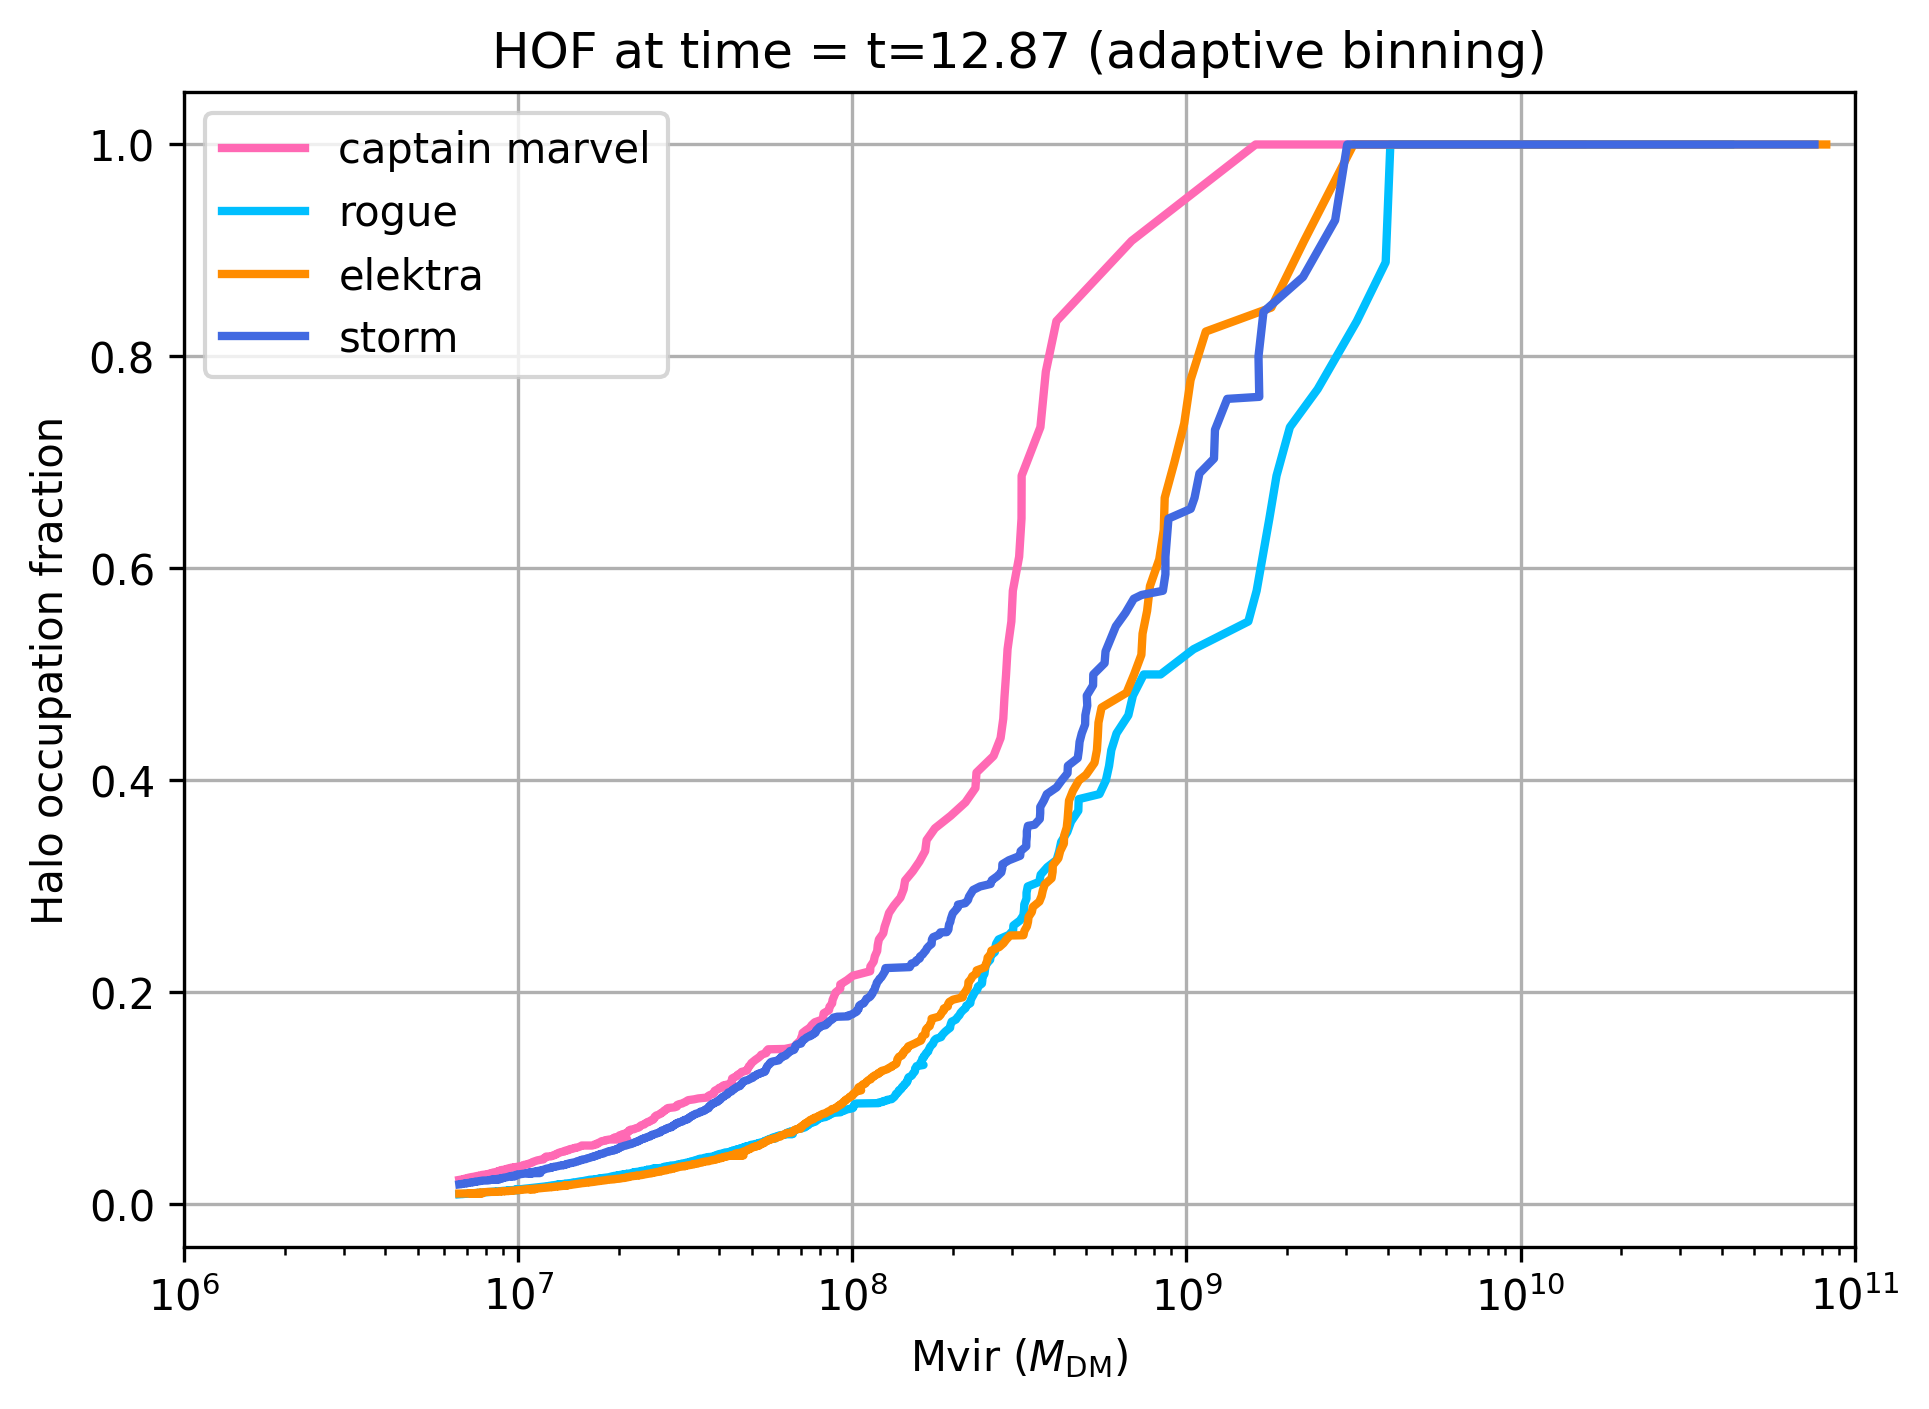

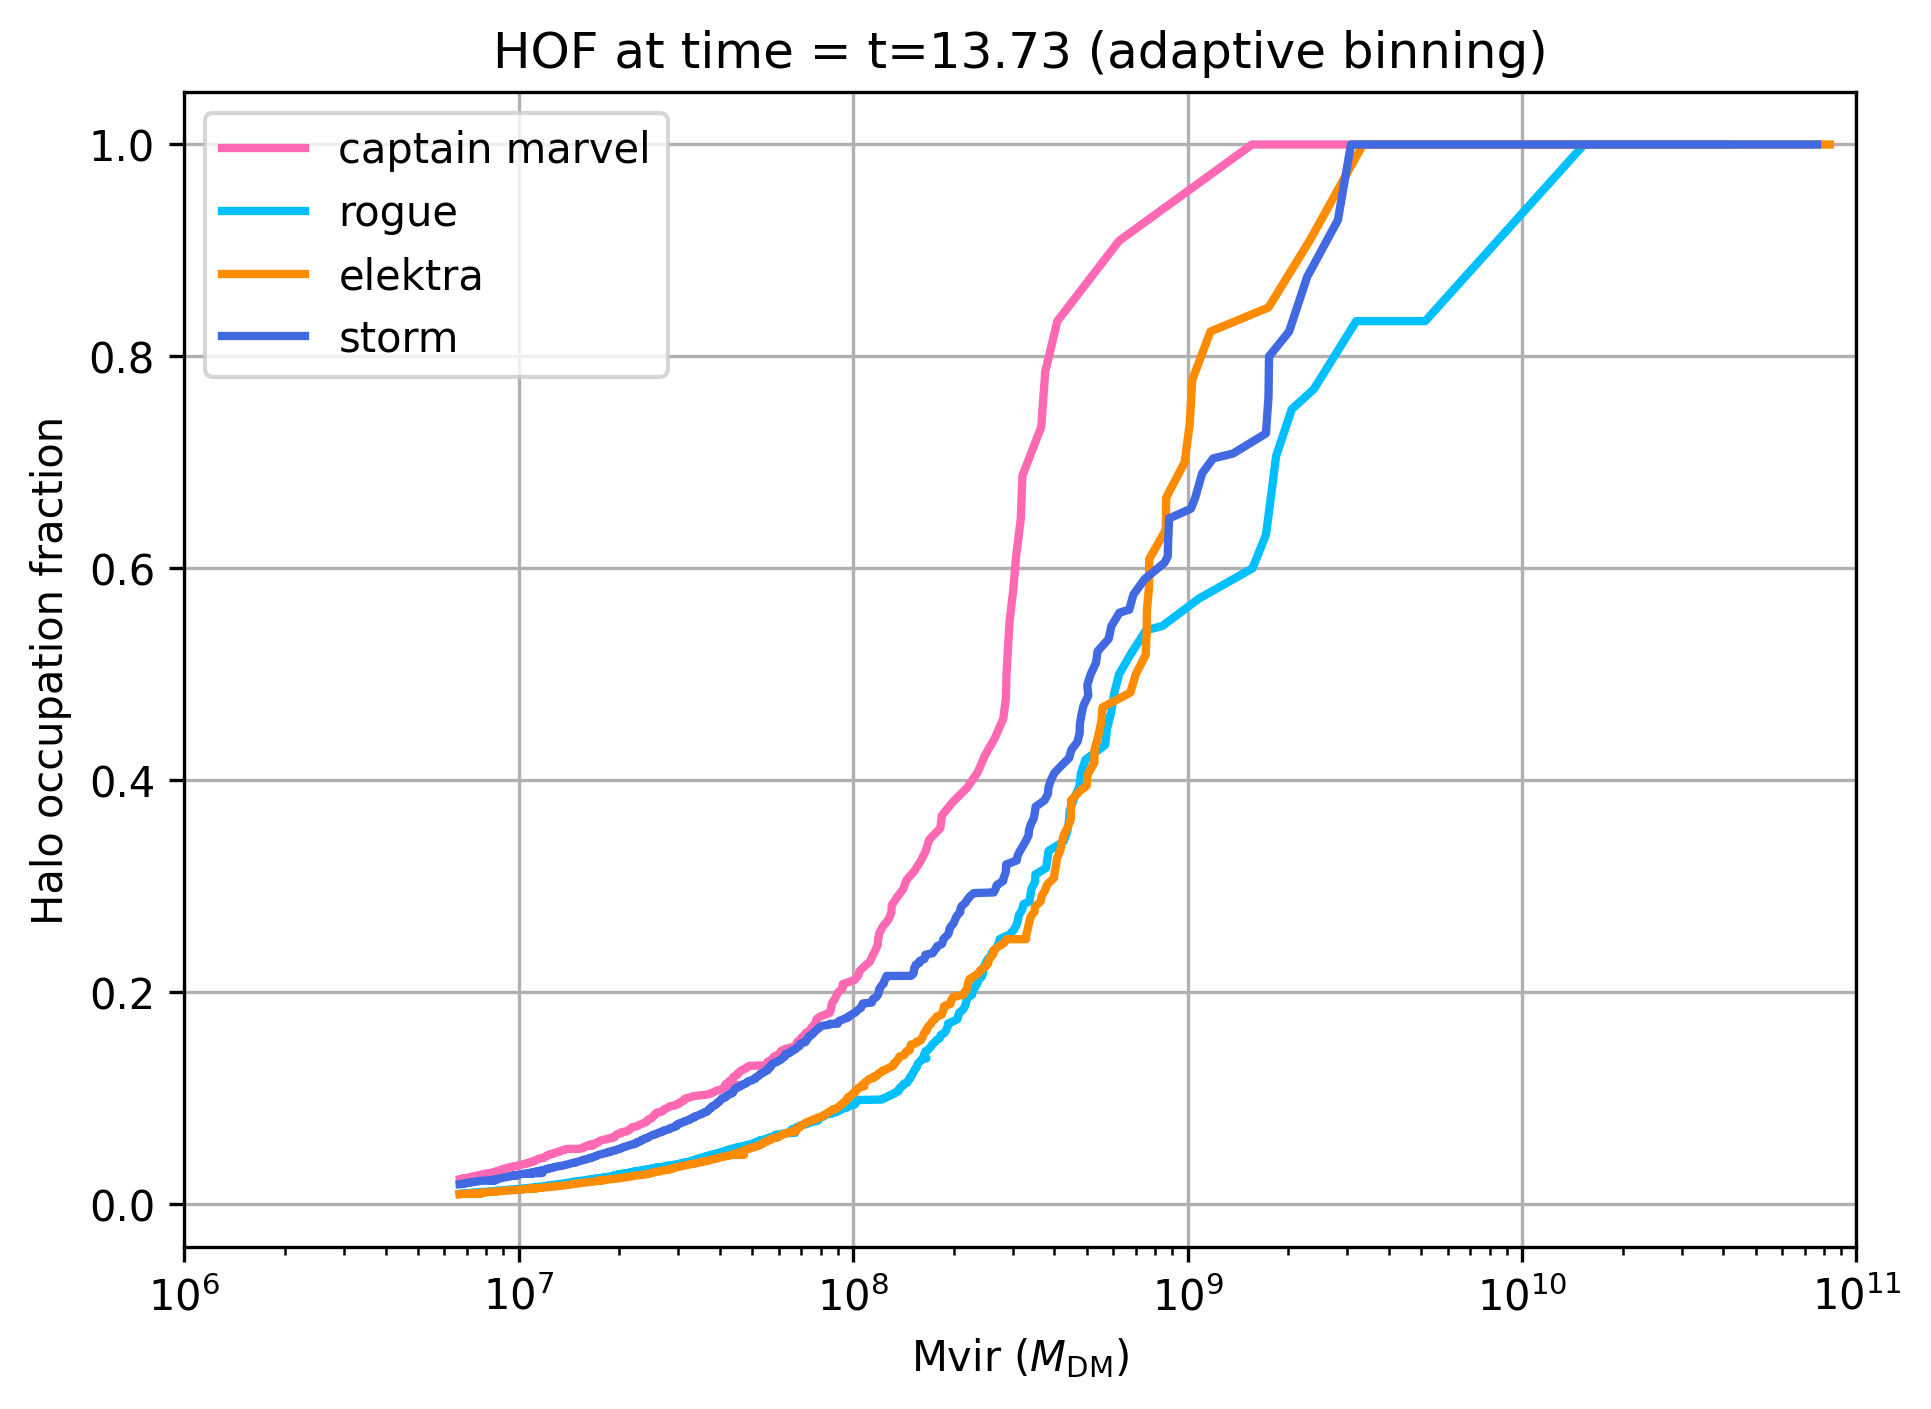

In [15]:
# HOF over time for Marvel sims using time grouping made by Anwar + adaptive binning 
"""
Cummulative HOF at all redshifts
Sims: Marvel partial_DB files
Adaptive binning
4/28/25, edited 6/26
"""

sim_names = ['cptmarvel', 'rogue', 'elektra', 'storm']
times = ['t=2.26', 't=2.58', 't=3.87', 't=5.16', 't=6.44', 't=7.73', 't=9.01', 't=10.30', 't=11.59', 't=12.87', 't=13.73']
n_sims = 4
n_timesteps = len(times)

# make plots
colors = np.array(['hotpink', 'deepskyblue', 'darkorange', 'royalblue'])
labels = np.array(['captain marvel', 'rogue', 'elektra', 'storm'])

zip_path = 'HOF_time_grouped.zip'

with zipfile.ZipFile(zip_path, 'r') as zipf:
    all_files = zipf.namelist()
    
    # get data at each redshift
    for t in range(n_timesteps):
    
        directory = f'HOF_time_grouped/{times[t]}/'
        files_in_t = [f for f in all_files if f.startswith(directory) and f.endswith('.txt')]
    
        plt.figure(dpi = 300)
        sim_num = 0
        
        # loop through each simulation at redshift z
        for file in files_in_t:
    
            with zipf.open(file) as f:
            
                data = np.genfromtxt(f, skip_header = 1, dtype=float, encoding='utf-8')
    
            # get and sort data
            masses = data[:,1]
            Nstars = data[:,2]
        
            occ_frac_data, DM_mass_data = adaptive_HOF(masses,Nstars)
            
            plt.semilogx(DM_mass_data, occ_frac_data, linestyle='-', linewidth = 2, color = colors[sim_num], label = labels[sim_num])
    
            sim_num += 1 
    
        plt.xlabel(r'Mvir ($M_\text{DM}$)')
        plt.ylabel('Halo occupation fraction')
        plt.title(f"HOF at time = {times[t]}")
        plt.grid(True)
        plt.tight_layout()
        plt.legend()
        plt.xlim(1e6,1e11)
        plt.show()
    

